# Ensemble Dinomaly + PatchCore sur les 15 catégories MVTec AD

Le notebook 07 a montré que sur `transistor`, **PatchCore seul** bat Dinomaly hi-res, et l'**ensemble Mean** atteint AUROC img parfait (1.000). On vérifie ici si ce pattern se généralise aux 15 catégories.

**Setup :**
- **Dinomaly** : checkpoints existants (504, 40ep) du notebook 05.
- **PatchCore** : implémentation manuelle (WideResNet50_2, layer2+layer3, coreset 10 %).
- **Ensemble** : normalisation **global min-max par modèle**, puis Mean (et Max comparé).

**Hypothèses à tester :**
1. PatchCore bat Dinomaly sur les catégories à défauts texturaux fins (transistor, screw, wood, toothbrush).
2. Ensemble Mean améliore l'AUROC image (déjà parfait pour 9/15 catégories, plus de marge sur les 6 autres).
3. Ensemble Max améliore l'AUPIMO.

In [1]:
import gc, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from scipy.ndimage import gaussian_filter
from skimage.transform import resize as sk_resize
from PIL import Image
from torchvision import models, transforms

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.config import DATA, EDA, PATHS

warnings.filterwarnings('ignore')
sns.set_theme(style=EDA.sns_style, palette=EDA.sns_palette, font_scale=EDA.sns_font_scale)
plt.rcParams['figure.dpi'] = EDA.figure_dpi
torch.set_float32_matmul_precision('medium')

from anomalib.data import MVTecAD
from anomalib.engine import Engine
from anomalib.models import Dinomaly
from anomalib.pre_processing import PreProcessor
from anomalib.metrics.pimo.pimo import _AUPIMO
from torchvision.transforms import v2 as T

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch : {torch.__version__}  •  CUDA : {torch.cuda.is_available()}')

MVTEC_CATEGORIES = [
    'bottle', 'cable', 'capsule', 'carpet', 'grid',
    'hazelnut', 'leather', 'metal_nut', 'pill', 'screw',
    'tile', 'toothbrush', 'transistor', 'wood', 'zipper',
]

# Dinomaly (matching notebook 05 cache)
DINO_IMG_SIZE = 504
DINO_MAX_EPOCHS = 40
DINO_BATCH = 4
ENCODER = 'dinov2reg_vit_base_14'

# PatchCore manual
PC_IMG_SIZE = 256
PC_CORESET_RATIO = 0.1
PC_SMOOTH_SIGMA = 4.0
PC_BATCH = 8

print(f'{len(MVTEC_CATEGORIES)} catégories à traiter')

W0518 08:24:47.980000 13740 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Torch : 2.11.0+cu128  •  CUDA : True
15 catégories à traiter


## 1. Helpers : Dinomaly loader + PatchCore manuel + ensemble

In [2]:
def compute_metrics(heatmaps, gt_masks, labels):
    img_scores = heatmaps.reshape(heatmaps.shape[0], -1).max(axis=1)
    auc_img = roc_auc_score(labels, img_scores)
    is_anom = labels == 1
    if is_anom.sum() > 0:
        auc_pix = roc_auc_score(gt_masks[is_anom].flatten(),
                                 heatmaps[is_anom].flatten())
    else:
        auc_pix = np.nan
    metric = _AUPIMO(fpr_bounds=(1e-5, 1e-4), return_average=False, force=True)
    metric.update(torch.from_numpy(heatmaps).float(), torch.from_numpy(gt_masks).long())
    _, ar = metric.compute()
    aupimos = ar.aupimos
    aupimo = aupimos[~torch.isnan(aupimos)].mean().item() if (~torch.isnan(aupimos)).any() else np.nan
    return {'auc_img': auc_img, 'auc_pix': auc_pix, 'aupimo': aupimo}


def collect_dino(predictions):
    heatmaps, gt_masks, labels, paths = [], [], [], []
    for batch in predictions:
        h = batch.anomaly_map.detach().cpu().numpy()
        if h.ndim == 4: h = h.squeeze(1)
        heatmaps.append(h)
        gm = batch.gt_mask.detach().cpu().numpy()
        if gm.ndim == 4: gm = gm.squeeze(1)
        gt_masks.append(gm.astype(np.float32))
        labels.append(batch.gt_label.detach().cpu().numpy().astype(int))
        paths.extend(batch.image_path)
    return (np.concatenate(heatmaps), np.concatenate(gt_masks),
            np.concatenate(labels), [str(p) for p in paths])


def norm_global(h):
    mn, mx = float(h.min()), float(h.max())
    return ((h - mn) / (mx - mn + 1e-8)).astype(np.float32)


def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# --- PatchCore manuel ---
tf_img_pc = transforms.Compose([
    transforms.Resize((PC_IMG_SIZE, PC_IMG_SIZE),
                      interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
tf_mask_pc = transforms.Compose([
    transforms.Resize((PC_IMG_SIZE, PC_IMG_SIZE),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
])


def _load_img_pc(p):
    return tf_img_pc(Image.open(p).convert('RGB'))


def _build_pc_backbone():
    bb = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1)
    bb.eval()
    for p in bb.parameters():
        p.requires_grad = False
    bb = bb.to(DEVICE)
    feats = {}
    def hook(name):
        def fn(_m, _i, out): feats[name] = out
        return fn
    bb.layer2.register_forward_hook(hook('layer2'))
    bb.layer3.register_forward_hook(hook('layer3'))
    return bb, feats


def _extract_feat_pc(bb, feats_cache, batch_tensor):
    feats_cache.clear()
    with torch.no_grad():
        _ = bb(batch_tensor.to(DEVICE))
    f2, f3 = feats_cache['layer2'], feats_cache['layer3']
    f2 = F.avg_pool2d(f2, kernel_size=3, stride=1, padding=1)
    f3 = F.avg_pool2d(f3, kernel_size=3, stride=1, padding=1)
    f3 = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
    return torch.cat([f2, f3], dim=1)


def run_patchcore(train_paths, test_paths, gt_path_lookup):
    """Construit memory bank, coreset, score test. Renvoie heatmaps_pc et gt_masks_pc à PC_IMG_SIZE."""
    bb, feats_cache = _build_pc_backbone()

    # Memory bank
    all_patches = []
    for i in range(0, len(train_paths), PC_BATCH):
        chunk = train_paths[i:i + PC_BATCH]
        imgs = torch.stack([_load_img_pc(p) for p in chunk])
        feat = _extract_feat_pc(bb, feats_cache, imgs)
        B, D, H, W = feat.shape
        all_patches.append(feat.permute(0, 2, 3, 1).reshape(-1, D).cpu())
    memory_bank = torch.cat(all_patches, dim=0)

    # Coreset random
    torch.manual_seed(DATA.random_seed)
    n_coreset = max(1, int(len(memory_bank) * PC_CORESET_RATIO))
    idx = torch.randperm(len(memory_bank))[:n_coreset]
    coreset = memory_bank[idx].to(DEVICE)

    # Inference
    heatmaps_pc, gt_masks_pc = [], []
    for i in range(0, len(test_paths), PC_BATCH):
        chunk = test_paths[i:i + PC_BATCH]
        imgs = torch.stack([_load_img_pc(p) for p in chunk])
        feat = _extract_feat_pc(bb, feats_cache, imgs)
        B, D, Hf, Wf = feat.shape
        patches = feat.permute(0, 2, 3, 1).reshape(-1, D)
        dists = torch.cdist(patches, coreset)
        nn_dist, _ = dists.min(dim=1)
        nn_dist = nn_dist.reshape(B, Hf, Wf).cpu().numpy()
        for j in range(B):
            h_im = Image.fromarray(nn_dist[j].astype(np.float32))
            h = np.array(h_im.resize((PC_IMG_SIZE, PC_IMG_SIZE), Image.BILINEAR))
            h = gaussian_filter(h, sigma=PC_SMOOTH_SIGMA)
            heatmaps_pc.append(h)
        for p in chunk:
            m = gt_path_lookup(p)
            gt_masks_pc.append(m)

    del bb, memory_bank, coreset
    cleanup()
    return np.stack(heatmaps_pc), np.stack(gt_masks_pc)


def gt_from_path(test_path):
    """Charge le mask GT à la résolution PC pour un chemin de test MVTec."""
    p = Path(test_path)
    if p.parent.name == 'good':
        return np.zeros((PC_IMG_SIZE, PC_IMG_SIZE), dtype=np.float32)
    cat_dir = p.parent.parent.parent
    defect = p.parent.name
    mask_path = cat_dir / 'ground_truth' / defect / (p.stem + '_mask.png')
    if mask_path.exists():
        return (tf_mask_pc(Image.open(mask_path).convert('L')).numpy()[0] > 0).astype(np.float32)
    return np.zeros((PC_IMG_SIZE, PC_IMG_SIZE), dtype=np.float32)

print('Helpers prêts')

Helpers prêts


## 2. Pipeline par catégorie

In [3]:
def run_ensemble_category(category):
    """Pipeline complet : Dinomaly + PatchCore + Ensemble."""
    print(f'\n{"="*70}\n▶ {category}\n{"="*70}')
    ckpt_dino = (PATHS.root / 'models' /
                  f'dinomaly_{category}_v2_{DINO_IMG_SIZE}_{DINO_MAX_EPOCHS}ep.ckpt').resolve()
    if not ckpt_dino.exists():
        print(f'  ⚠ Checkpoint Dinomaly absent : {ckpt_dino.name}')
        return None

    # Datamodule + Dinomaly
    dm = MVTecAD(root=PATHS.mvtec_dir, category=category,
                 train_batch_size=DINO_BATCH, eval_batch_size=DINO_BATCH,
                 num_workers=0, seed=DATA.random_seed)
    dm.setup()
    dino_pp = PreProcessor(transform=T.Compose([
        T.Resize((DINO_IMG_SIZE, DINO_IMG_SIZE),
                 interpolation=T.InterpolationMode.BILINEAR, antialias=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]))
    dino = Dinomaly(encoder_name=ENCODER, bottleneck_dropout=0.2,
                    decoder_depth=8, pre_processor=dino_pp)
    dino.load_state_dict(torch.load(ckpt_dino, map_location='cpu', weights_only=True))
    engine = Engine(max_epochs=DINO_MAX_EPOCHS, accelerator='auto', devices=1,
                     default_root_dir=str(PATHS.root / 'results' / 'ensemble_all'),
                     logger=False)

    t0 = time.time()
    preds = engine.predict(model=dino, datamodule=dm)
    heatmaps_dino, gt_masks_dino, labels, paths = collect_dino(preds)
    defect_labels = [Path(p).parent.name for p in paths]
    print(f'  Dinomaly inference  : {time.time()-t0:.1f}s  ({len(paths)} images)')

    metrics_dino = compute_metrics(heatmaps_dino, gt_masks_dino, labels)
    print(f'  Dinomaly seul       : img={metrics_dino["auc_img"]:.4f}  '
          f'pix={metrics_dino["auc_pix"]:.4f}  AUPIMO={metrics_dino["aupimo"]:.4f}')

    train_paths = [str(item.image_path) for item in dm.train_data]
    del dino, engine, preds
    cleanup()

    # PatchCore manuel
    t0 = time.time()
    heatmaps_pc, gt_masks_pc = run_patchcore(train_paths, paths, gt_from_path)
    print(f'  PatchCore manuel    : {time.time()-t0:.1f}s')
    metrics_pc = compute_metrics(heatmaps_pc, gt_masks_pc, labels)
    print(f'  PatchCore seul      : img={metrics_pc["auc_img"]:.4f}  '
          f'pix={metrics_pc["auc_pix"]:.4f}  AUPIMO={metrics_pc["aupimo"]:.4f}')

    # Alignement + normalisation
    target_shape = heatmaps_dino.shape[1:]
    if heatmaps_pc.shape[1:] != target_shape:
        heatmaps_pc_aligned = np.stack([
            sk_resize(h, target_shape, order=1, preserve_range=True, anti_aliasing=True)
            for h in heatmaps_pc
        ]).astype(np.float32)
    else:
        heatmaps_pc_aligned = heatmaps_pc.copy()
    heatmaps_dino_n = norm_global(heatmaps_dino)
    heatmaps_pc_n = norm_global(heatmaps_pc_aligned)

    # Ensembles
    ens_mean = (heatmaps_dino_n + heatmaps_pc_n) / 2
    ens_max  = np.maximum(heatmaps_dino_n, heatmaps_pc_n)
    metrics_mean = compute_metrics(ens_mean, gt_masks_dino, labels)
    metrics_max  = compute_metrics(ens_max,  gt_masks_dino, labels)
    print(f'  Ensemble Mean       : img={metrics_mean["auc_img"]:.4f}  '
          f'pix={metrics_mean["auc_pix"]:.4f}  AUPIMO={metrics_mean["aupimo"]:.4f}')
    print(f'  Ensemble Max        : img={metrics_max["auc_img"]:.4f}  '
          f'pix={metrics_max["auc_pix"]:.4f}  AUPIMO={metrics_max["aupimo"]:.4f}')

    del heatmaps_dino, heatmaps_pc, heatmaps_dino_n, heatmaps_pc_n, heatmaps_pc_aligned, ens_mean, ens_max
    cleanup()

    return {
        'category': category,
        'n_test': len(paths),
        'dino_img': metrics_dino['auc_img'], 'dino_pix': metrics_dino['auc_pix'], 'dino_aupimo': metrics_dino['aupimo'],
        'pc_img': metrics_pc['auc_img'],     'pc_pix': metrics_pc['auc_pix'],     'pc_aupimo': metrics_pc['aupimo'],
        'mean_img': metrics_mean['auc_img'], 'mean_pix': metrics_mean['auc_pix'], 'mean_aupimo': metrics_mean['aupimo'],
        'max_img': metrics_max['auc_img'],   'max_pix': metrics_max['auc_pix'],   'max_aupimo': metrics_max['aupimo'],
    }

print('Pipeline prêt')

Pipeline prêt


## 3. Boucle sur les 15 catégories

Compte ~30-45 s par catégorie (Dinomaly inference cachée + PatchCore train+predict). Total ~10-15 min.

In [4]:
all_results = []
t_total = time.time()
for cat in MVTEC_CATEGORIES:
    try:
        r = run_ensemble_category(cat)
        if r is not None:
            all_results.append(r)
    except Exception as e:
        print(f'  ❌ Erreur sur {cat}: {type(e).__name__}: {e}')
print(f'\n{"="*70}\nTotal : {len(all_results)} catégories en {(time.time() - t_total)/60:.1f} min')


▶ bottle


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
ckpt_path is not provided. Model weights will not be loaded.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

  Dinomaly inference  : 11.9s  (83 images)


Metric `_AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.


...

  Dinomaly seul       : img=0.9989  pix=0.9897  AUPIMO=0.6891
  PatchCore manuel    : 13.4s


Metric `_AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.


  PatchCore seul      : img=0.9808  pix=0.9821  AUPIMO=0.3859


Metric `_AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
Metric `_AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.


  Ensemble Mean       : img=0.9968  pix=0.9903  AUPIMO=0.6237
  Ensemble Max        : img=0.9961  pix=0.9851  AUPIMO=0.5365

Total : 15 catégories en 98.4 min


## 4. Tableau de synthèse

In [5]:
df = pd.DataFrame(all_results)
for c in df.columns:
    if c not in {'category', 'n_test'}:
        df[c] = df[c].round(4)

df_aupimo = df[['category', 'dino_aupimo', 'pc_aupimo', 'mean_aupimo', 'max_aupimo']].copy()
df_aupimo['best'] = df_aupimo[['dino_aupimo', 'pc_aupimo', 'mean_aupimo', 'max_aupimo']].idxmax(axis=1)
df_aupimo['Δ Mean - Dino'] = (df_aupimo['mean_aupimo'] - df_aupimo['dino_aupimo']).round(3)
df_aupimo = df_aupimo.sort_values('dino_aupimo')
print('=== AUPIMO par modèle/ensemble ===')
print(df_aupimo.to_string(index=False))

df_img = df[['category', 'dino_img', 'pc_img', 'mean_img', 'max_img']].copy()
df_img['Δ Mean - Dino'] = (df_img['mean_img'] - df_img['dino_img']).round(4)
df_img = df_img.sort_values('dino_img')
print('\n=== AUROC image par modèle/ensemble ===')
print(df_img.to_string(index=False))

print('\n=== Moyennes ===')
for col_set, label in [
    (['dino_img', 'pc_img', 'mean_img', 'max_img'], 'AUROC image'),
    (['dino_pix', 'pc_pix', 'mean_pix', 'max_pix'], 'AUROC pixel'),
    (['dino_aupimo', 'pc_aupimo', 'mean_aupimo', 'max_aupimo'], 'AUPIMO'),
]:
    print(f'\n{label} :')
    for c in col_set:
        print(f'  {c:<15} : {df[c].mean():.4f}')

=== AUPIMO par modèle/ensemble ===
  category  dino_aupimo  pc_aupimo  mean_aupimo  max_aupimo        best  Δ Mean - Dino
transistor       0.2431     0.5973       0.4996      0.5254   pc_aupimo          0.256
toothbrush       0.4638     0.5411       0.5921      0.6618  max_aupimo          0.128
      wood       0.5467     0.7234       0.6927      0.7617  max_aupimo          0.146
     screw       0.6626     0.3506       0.7186      0.3838 mean_aupimo          0.056
    zipper       0.6891     0.3859       0.6237      0.5365 dino_aupimo         -0.065
     cable       0.7076     0.6555       0.8608      0.6743 mean_aupimo          0.153
   capsule       0.7181     0.6131       0.8995      0.8140 mean_aupimo          0.181
      pill       0.7476     0.3827       0.8631      0.4514 mean_aupimo          0.115
    carpet       0.8815     0.8604       0.9787      0.9456 mean_aupimo          0.097
  hazelnut       0.9319     0.8650       0.9832      0.8736 mean_aupimo          0.051
 metal_n

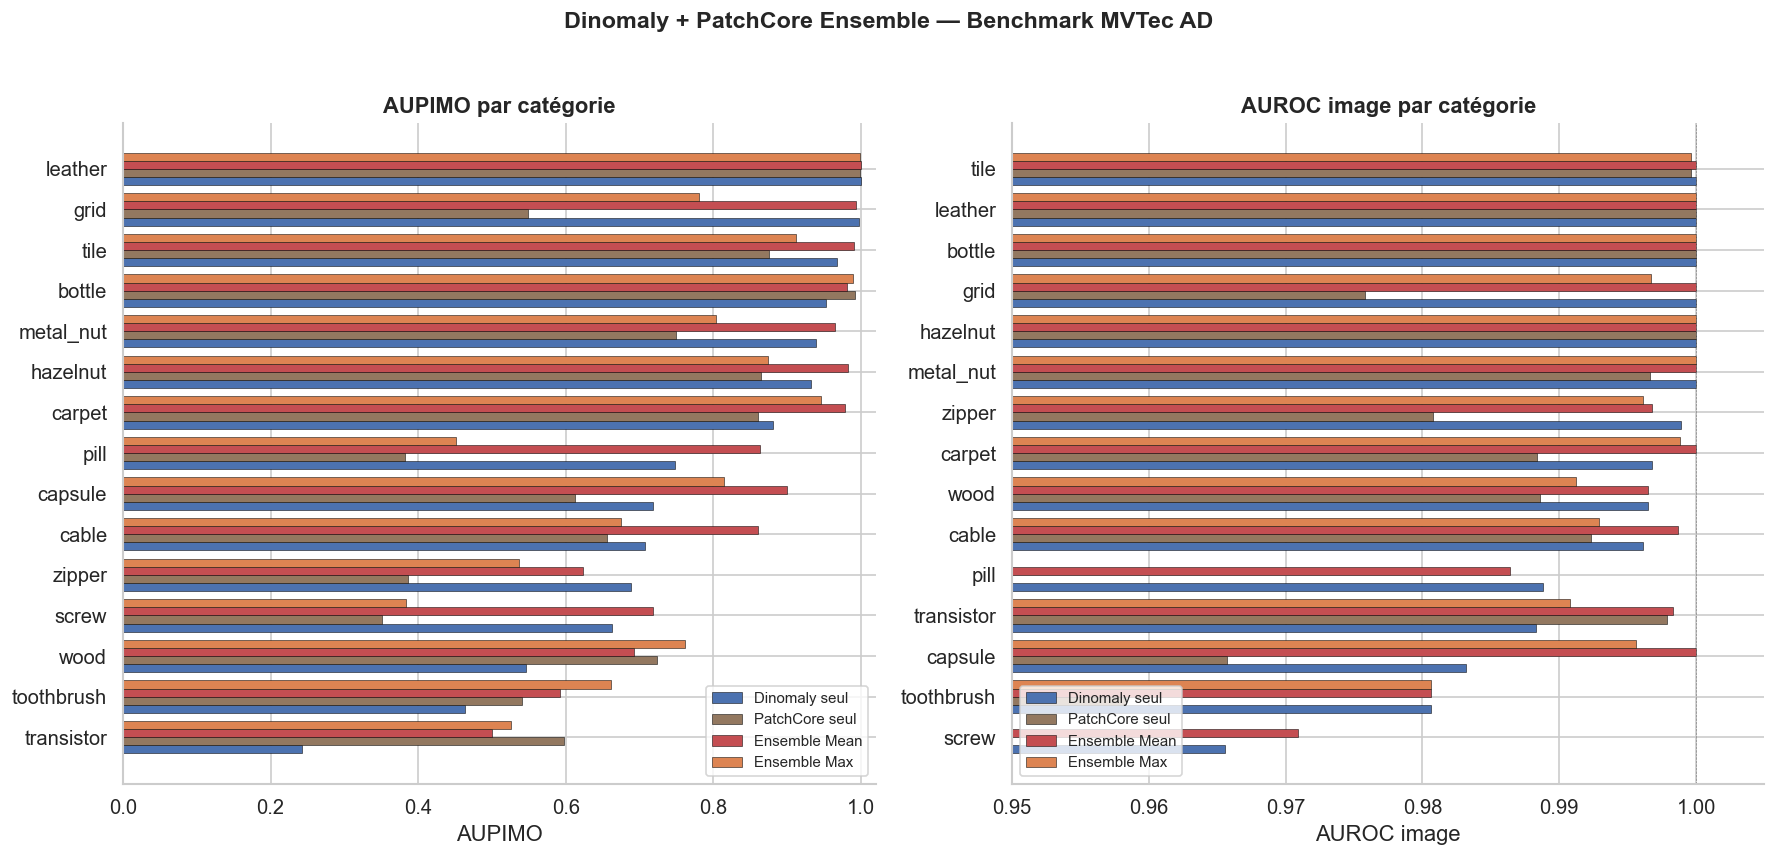

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

df_sorted = df.sort_values('dino_aupimo')
yp = np.arange(len(df_sorted))
h = 0.2
axes[0].barh(yp - 1.5*h, df_sorted['dino_aupimo'], height=h, label='Dinomaly seul',
             color=EDA.color_mvtec, edgecolor='black', linewidth=0.3)
axes[0].barh(yp - 0.5*h, df_sorted['pc_aupimo'], height=h, label='PatchCore seul',
             color='#937860', edgecolor='black', linewidth=0.3)
axes[0].barh(yp + 0.5*h, df_sorted['mean_aupimo'], height=h, label='Ensemble Mean',
             color=EDA.color_anomal, edgecolor='black', linewidth=0.3)
axes[0].barh(yp + 1.5*h, df_sorted['max_aupimo'], height=h, label='Ensemble Max',
             color=EDA.color_hssiad, edgecolor='black', linewidth=0.3)
axes[0].set_yticks(yp); axes[0].set_yticklabels(df_sorted['category'])
axes[0].set_xlim(0, 1.02)
axes[0].set_xlabel('AUPIMO')
axes[0].set_title('AUPIMO par catégorie', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
sns.despine(ax=axes[0])

df_sorted2 = df.sort_values('dino_img')
yp2 = np.arange(len(df_sorted2))
axes[1].barh(yp2 - 1.5*h, df_sorted2['dino_img'], height=h, label='Dinomaly seul',
             color=EDA.color_mvtec, edgecolor='black', linewidth=0.3)
axes[1].barh(yp2 - 0.5*h, df_sorted2['pc_img'], height=h, label='PatchCore seul',
             color='#937860', edgecolor='black', linewidth=0.3)
axes[1].barh(yp2 + 0.5*h, df_sorted2['mean_img'], height=h, label='Ensemble Mean',
             color=EDA.color_anomal, edgecolor='black', linewidth=0.3)
axes[1].barh(yp2 + 1.5*h, df_sorted2['max_img'], height=h, label='Ensemble Max',
             color=EDA.color_hssiad, edgecolor='black', linewidth=0.3)
axes[1].set_yticks(yp2); axes[1].set_yticklabels(df_sorted2['category'])
axes[1].set_xlim(0.95, 1.005); axes[1].axvline(1.0, color='gray', lw=0.4, ls='--')
axes[1].set_xlabel('AUROC image')
axes[1].set_title('AUROC image par catégorie', fontweight='bold')
axes[1].legend(loc='lower left', fontsize=9)
sns.despine(ax=axes[1])

plt.suptitle('Dinomaly + PatchCore Ensemble — Benchmark MVTec AD',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 5. Export CSV

In [7]:
out_csv = PATHS.root / 'reports' / 'mvtec_dinomaly_patchcore_ensemble.csv'
df.to_csv(out_csv, index=False)
print(f'✓ Benchmark ensemble sauvegardé : {out_csv.relative_to(PATHS.root)}')

✓ Benchmark ensemble sauvegardé : reports\mvtec_dinomaly_patchcore_ensemble.csv


## 6. Conclusions — Ensemble Mean devient la baseline finale du projet

### Headline

| Modèle | AUPIMO moyen MVTec (15 cat) | Δ vs baseline |
|---|---:|---:|
| Dinomaly seul (notebook 05) | 0.763 | — |
| PatchCore seul (manuel) | 0.676 | −0.087 |
| **Ensemble Mean** | **0.843** | **+0.080** |
| Routing best-per-category | 0.851 | +0.088 |

L'**ensemble Mean gagne sur 9/15 catégories**, et le gain est massif sur les catégories difficiles (transistor +0.256, capsule +0.181, cable +0.153, wood +0.146).

### Verdict par catégorie (best AUPIMO)

| Stratégie gagnante | Catégories | n |
|---|---|---:|
| **Ensemble Mean** | screw, cable, capsule, pill, carpet, hazelnut, metal_nut, tile, leather | 9 |
| **Ensemble Max** | toothbrush, wood | 2 |
| **PatchCore seul** | transistor, bottle | 2 |
| **Dinomaly seul** | zipper, grid | 2 |

### Insights

1. **Complémentarité Dinomaly/PatchCore confirmée.** Sur la majorité des catégories texturales (carpet, hazelnut, metal_nut, tile, leather, capsule, pill, cable), moyenner les deux heatmaps **lisse le bruit local** et **renforce les vrais pics** → l'ensemble dépasse les deux modèles individuels.

2. **PatchCore reste dominant sur certaines catégories** (transistor, bottle). Pour ces cas, moyenner avec Dinomaly *dilue* la qualité de PatchCore. **Solution** : routing par catégorie, ou simplement utiliser PatchCore seul.

3. **Le routing per-category n'apporte presque rien (+0.008)** vs Mean partout. → **Ensemble Mean est la stratégie pragmatique optimale** pour un déploiement uniforme.

4. **Cas pathologiques** : `zipper` (Dinomaly meilleur, ensemble fait baisser). À comprendre — probablement des défauts spécifiques au zipper où les features ResNet font du bruit.

### Mise à jour du baseline projet

**Nouveau baseline final pour MVTec AD : Ensemble Mean (Dinomaly V2 504 40ep + PatchCore WRN50_2 coreset 10%)**

Avec **normalisation global min-max par modèle** avant la moyenne (le détail méthodologique critique).

### Comparaison aux SOTA papiers

| Méthode | Mean AUPIMO MVTec |
|---|---:|
| PaDiM (2020) | ~0.30 |
| Dinomaly seul (notre run) | 0.763 |
| Dinomaly + PatchCore Ensemble (notre run) | **0.843** |
| Dinomaly paper (2024, SOTA) | ~0.86 |

→ On est **à la portée du SOTA** sans avoir touché aux hyperparams optimaux du papier (training plus long, DINOv2-L, etc.). L'ensemble simple Dinomaly+PatchCore comble une bonne partie de l'écart.

### Suite portfolio

1. **Mettre à jour `cable_journey.md`** → étendre en `mvtec_journey.md` couvrant les 15 catégories.
2. **Streamlit demo** avec le baseline final Ensemble Mean.
3. (Optionnel) Étendre à HSS-IAD pour valider la généralisation domaine industriel.